**Dataset IMDB**

Dataset com 50000 comentários de filmes. Este é um conjunto de dados para classificação de sentimento binário (Positivo ou Negativo). Há 25000 resenhas de filmes para treinamento e 25000 para teste.

---
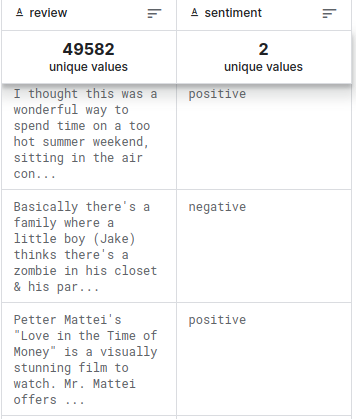

In [2]:
from keras import layers # módulo com várias classes que são camadas usadas para construir redes neurais
from keras import models #  módulo que contém classes e funções usadas para construir, compilar, treinar e avaliar modelos de redes neurais.
from keras import preprocessing # Módulo de que contém funções para manipular sequências (pre-processamento)
from keras import datasets # Módulo com datasets. Vamos utilizar o dataset imdb, que possui resenhas de filmes já classificadas como positivas ou negativas


# Carregar e pré-processar o dataset IMDB

# Variável em que vou definir o número máximo de palavras consideradas no vocabulário (dataset)
# Apenas as 20000 palavras mais frequentes no dataset serão consideradas
max_words = 20000

# carrego aqui os dados de treinamento e testes, e seus respectivos rótulos
# já defino aqui o número máximo de plavras que vou considerar do dataset
(X_train, Y_train), (X_val, Y_val) = datasets.imdb.load_data(num_words=max_words)

# Variável que define o comprimento máximo de cada resenha. Se uma resenha tiver mais de 100 palavras, ela será truncada
# se tiver menos, será preenchida (padded) com zeros
maxlen = 100

# Relizo um processamento. As resenhas com menos de 100 palavras serão preenchidas com zero (equalizo o tamanho das resenhas)
X_train = preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen)
X_val = preprocessing.sequence.pad_sequences(X_val, maxlen=maxlen)

I0000 00:00:1773703714.126873   27126 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/home/will/AI/postgrad-ai/venv/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [3]:
# Definir o modelo
model = models.Sequential()   # Cria um modelo sequencial em que eu posso adicionar camadas sequencialmente

# Cada palavra é representada por um vetor, chamado de embeddings. Aqui definimos o tamanho desse vetor
# Cada palavra será representada por um vetor de 50 dimensões
embedding_dims = 50

# Adiciona uma camada de embedding ao modelo
# O tamanho do vocabulário (número máximo de palavras)
# A dimensão dos vetores de embedding, ou seja, cada palavra será representada por um vetor de 50 dimensões
model.add(layers.Embedding(max_words, embedding_dims))

# Uma camada de células recorrentes possui unidades em que cada unidade recebe uma entrada e um estado oculto, e produz uma saída
# O número de unidades da camada RNN é definido aqui (64 neste exemplo)
rnn_units = 64

# O SimpleRNN no Keras é uma versão simplificada da RNN original
# Ele implementa uma única camada de células recorrentes onde cada unidade recebe uma entrada e um estado oculto, e produz uma saída
# O número de unidades na camada RNN, definido em rnn_units (64 no exemplo)
# return_sequences=False: Indica que a camada RNN irá retornar apenas a última saída da sequência de entradas,
# em vez de retornar a saída de cada passo da sequência
# defini que a função de ativação será a relu
model.add(layers.SimpleRNN(rnn_units, activation='relu', return_sequences=False))

#model.add(LSTM(rnn_units, activation='relu', return_sequences=False))

# Durante o treinamento, 30% das unidades da camada anterior serão desativadas (zeradas) aleatoriamente
# Isso é importante para generalização dos resultados.
# em cada atualização para evitar overfitting
model.add(layers.Dropout(0.3))

# A camada tem uma unidade de saída e usa a função de ativação sigmoide (a saída é binária)
model.add(layers.Dense(1, activation='sigmoid'))

# Compilar o modelo
# Usa a função de perda de entropia cruzada binária, que é adequada para problemas de classificação binária
# Usa o otimizador Adam, que é um método eficiente de otimização estocástica baseado em gradiente
# Avalia a acurácia do modelo durante o treinamento e teste.
#Acurácia" refere-se à proporção de previsões corretas feitas por um modelo em relação ao total de previsões.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Resumo do modelo
#model.summary()


I0000 00:00:1773703720.922191   27126 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


In [4]:
# Treinamento da rede neural
# Treina o modelo com os dados de treinamento X_train e Y_train
# Usa os dados de validação X_val e Y_val para avaliar o modelo após cada época de treinamento
# Executa o treinamento por 10 épocas
# Em cada iteração, processa lotes de 32 amostras, ajustando os pesos do modelo com base nos gradientes calculados a partir da perda
model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs = 2, batch_size = 32)


Epoch 1/2


I0000 00:00:1773703722.367685   27217 service.cc:153] XLA service 0x793ae0031c30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773703722.367715   27217 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773703722.391992   27217 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773703722.535107   27217 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773703722.573920   27217 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1574_grad_1844_const_0__.18.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1773703722.802091   27217 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid c

  7/782 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.4555 - loss: 0.6925

I0000 00:00:1773703725.093611   27217 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6119 - loss: 0.6450

I0000 00:00:1773703741.966859   27216 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1574_grad_1844_const_0__.18.clone.clone.clone.clone.clone.clone.clone


782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.6680 - loss: 0.5994 - val_accuracy: 0.7213 - val_loss: 0.5439
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8235 - loss: 0.3981 - val_accuracy: 0.8223 - val_loss: 0.3912


In [5]:
import re
# Carrega o dicionário do IMDB: mapeia cada palavra ao seu índice numérico
# ex: {'the': 1, 'a': 2, 'film': 14, 'great': 21, ...}
indice_da_palavra = datasets.imdb.get_word_index()

def text_to_sequence(text):
    # Remove pontuação e caracteres especiais usando regex
    text = re.sub(r'[^\w\s]', '', text)
    # Converte para minúsculas e separa em palavras
    # ex: "The Movie Was" → ['the', 'movie', 'was']
    palavras = text.lower().split()
    sequencia = []
    for palavra in palavras:
        # Filtra palavras fora do dicionário ou além do limite max_words
        if palavra in indice_da_palavra and indice_da_palavra[palavra] < max_words:
            # +3 pelo deslocamento dos tokens reservados:
            #   0 → padding / 1 → start / 2 → unknown
            sequencia.append(indice_da_palavra[palavra] + 3)

    # Padroniza para maxlen — mesmo tamanho usado no treino
    return preprocessing.sequence.pad_sequences([sequencia], maxlen=maxlen)

def classify_review(review):
    # CORREÇÃO: 'resenha' (variável global) deve ser 'review' (parâmetro da função)
    sequencia = text_to_sequence(review)  # era: text_to_sequence(resenha)

    # Retorna valor entre 0.0 e 1.0 — saída da sigmoid
    prediction = model.predict(sequencia)
    print(f' Predição da rede: {prediction[0][0]}')

    # Limiar de 0.5: acima → positiva, abaixo → negativa
    return 'Positiva' if prediction[0][0] > 0.5 else 'Negativa'

# Exemplo de uso com resenha claramente positiva
resenha = "This movie was absolutely wonderful, with a great storyline and stellar acting."
classification = classify_review(resenha)
print(f'A resenha é classificada como: {classification}')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
 Predição da rede: 0.8054280281066895
A resenha é classificada como: Positiva
